# Nauka modelu ResNet

#### importy

In [38]:
import torch
import torchvision
import torchvision.transforms as transforms 
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report
from PIL import Image
import optuna
from optuna.integration import PyTorchLightningPruningCallback
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning import LightningModule, Trainer
import json
import warnings
from pytorch_lightning.callbacks import RichProgressBar
from pytorch_lightning.callbacks.progress.rich_progress import RichProgressBarTheme
warnings.filterwarnings('ignore')

In [39]:
torch.set_float32_matmul_precision('high')

In [40]:
seed = 1

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [42]:
EPOCHS = 300

## Dane

### Transformacje danych

In [ ]:
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_preview = transforms.Compose([transforms.ToTensor()])

### Pobieranie zbiorów danych

In [44]:
full_trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=None)

train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = torch.utils.data.random_split(full_trainset, [train_size, val_size])
trainset.dataset.transform = transform

testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=512, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

trainset_preview = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_preview)
previewloader = torch.utils.data.DataLoader(trainset_preview, batch_size=16, shuffle=True)

In [45]:
classes = trainset.dataset.classes
classes

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

In [46]:
def imshow(img, labels):
    npimg = img.numpy()
    plt.figure(figsize=(12, 6))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    
    # Dodawanie etykiet
    title = ", ".join([classes[labels[j]] for j in range(len(labels))])
    plt.title(f"Przykładowe klasy:\n{title}", fontsize=10, wrap=True)
    plt.axis('off')
    plt.show()

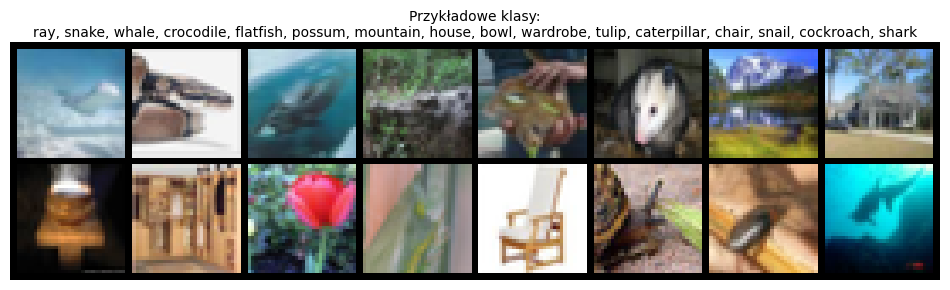

In [47]:
dataiter = iter(previewloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images, nrow=8), labels)

# Trening Czysty

### Klasa Trainer

In [48]:
class ResNetLightning(LightningModule):
    def __init__(self, lr=0.1, momentum=0.9, weight_decay=5e-4, T_max=280):
        super().__init__()
        self.model = models.resnet18(weights=None, num_classes=100)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()
        self.criterion = nn.CrossEntropyLoss()
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.T_max = T_max
        
    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log('test_loss', loss, prog_bar=True)
        self.log('test_acc', acc, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        optimizer = optim.SGD(
            self.parameters(), 
            lr=self.lr, 
            momentum=self.momentum, 
            weight_decay=self.weight_decay
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.T_max)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch'
            }
        }

### Optymalizacja hiperparametrów z Optuną

In [51]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-3, 0.15, log=True)
    momentum = trial.suggest_float('momentum', 0.6, 0.99)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    
    model = ResNetLightning(lr=lr, momentum=momentum, weight_decay=weight_decay)
    
    trainer = Trainer(
        max_epochs=20,
        enable_progress_bar=False,
        precision='bf16-mixed',
        callbacks=[PyTorchLightningPruningCallback(trial, monitor='val_acc')],
        enable_model_summary=False,
        logger=False,
        enable_checkpointing=False
    )
    
    trainer.fit(model, trainloader, valloader)
    
    return trainer.callback_metrics['val_acc'].item()


In [52]:
print("Rozpoczęcie optymalizacji hiperparametrów...")
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=20)

print("\nNajlepsze parametry:", study.best_params)
print("Najlepsza dokładność walidacyjna:", f"{study.best_value:.4f}")

[I 2026-04-23 01:59:50,417] A new study created in memory with name: no-name-630cd535-28b7-4d87-90bf-333abe088145
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Rozpoczęcie optymalizacji hiperparametrów...


`Trainer.fit` stopped: `max_epochs=20` reached.
[I 2026-04-23 02:01:30,180] Trial 0 finished with value: 0.28209999203681946 and parameters: {'lr': 0.004202388975361907, 'momentum': 0.8399062495839477, 'weight_decay': 3.2369454088881623e-05}. Best is trial 0 with value: 0.28209999203681946.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=20` reached.
[I 2026-04-23 02:03:10,064] Trial 1 finished with value: 0.2727999985218048 and parameters: {'lr': 0.008099451929275537, 'momentum': 0.6960546516474229, 'weight_decay': 2.1358554143427947e-05}. Best is trial 0 with value: 0.28209999203681946.
Using bfloat16 Aut


Najlepsze parametry: {'lr': 0.13538101467598074, 'momentum': 0.8531894286443445, 'weight_decay': 0.0002096500672245628}
Najlepsza dokładność walidacyjna: 0.5764


In [53]:
best_params_path = "./optuna_params/resnet18md-batch512-clean.json"

In [54]:
with open(best_params_path, "w") as f:
    json.dump(study.best_params, f, indent=4)

print(f"Najlepsze parametry zostały zapisane do pliku: {best_params_path}")

Najlepsze parametry zostały zapisane do pliku: ./optuna_params/resnet18md-batch512-clean.json


### Funkcje pomocnicze

In [55]:
from pytorch_lightning.callbacks import Callback

class MetricsCollector(Callback):
    """Callback do zbierania metryk z każdej epoki"""
    def __init__(self):
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    def on_train_epoch_end(self, trainer, pl_module):
        # Pobierz metryki treningowe
        if 'train_loss' in trainer.callback_metrics:
            self.history['train_loss'].append(trainer.callback_metrics['train_loss'].item())
        if 'train_acc' in trainer.callback_metrics:
            self.history['train_acc'].append(trainer.callback_metrics['train_acc'].item() * 100)
    
    def on_validation_epoch_end(self, trainer, pl_module):
        # Pobierz metryki walidacyjne
        if 'val_loss' in trainer.callback_metrics:
            self.history['val_loss'].append(trainer.callback_metrics['val_loss'].item())
        if 'val_acc' in trainer.callback_metrics:
            self.history['val_acc'].append(trainer.callback_metrics['val_acc'].item() * 100)

def print_training_plot(metrics_collector, name='training_history.png'):
    """
    Rysuje wykresy loss i accuracy na podstawie historii z MetricsCollector
    
    Args:
        metrics_collector: Obiekt MetricsCollector zawierający historię treningu
        name: Nazwa pliku do zapisania wykresu
    """
    history = metrics_collector.history
    
    plt.figure(figsize=(14, 5))

    # Wykres Straty (Loss)
    plt.subplot(1, 2, 1)
    if history['train_loss']:
        plt.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=1.5)
    if history['val_loss']:
        plt.plot(history['val_loss'], label='Val Loss', marker='o', linewidth=1.5)
    plt.title('Krzywa Straty (Loss)', fontsize=12, fontweight='bold')
    plt.xlabel('Epoka')
    plt.ylabel('Strata')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Wykres Dokładności (Accuracy)
    plt.subplot(1, 2, 2)
    if history['train_acc']:
        plt.plot(history['train_acc'], label='Train Acc', marker='o', linewidth=1.5)
    if history['val_acc']:
        plt.plot(history['val_acc'], label='Val Acc', marker='o', linewidth=1.5)
    plt.title('Krzywa Dokładności (Accuracy)', fontsize=12, fontweight='bold')
    plt.xlabel('Epoka')
    plt.ylabel('Dokładność (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(name)
    print(f"Wykres zapisany jako '{name}'")
    plt.show()

def training_report(model, testloader):
    model.to(device)
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in tqdm(testloader, desc="Zbieranie predykcji"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())

    report = classification_report(all_targets, all_preds, target_names=classes, zero_division=0)
    print("\n### RAPORT KLASYFIKACJI ###\n")
    print(report)

### Trening z najlepszymi hiperparametrami

In [ ]:
checkpoint_callback = ModelCheckpoint(
    dirpath='model_checkpoints/',
    filename='resnet18-batch512-cifar100-{epoch:02d}-{val_acc:.2f}',
    every_n_epochs=25,
    save_top_k=3,
    monitor='val_acc',
    mode='max'
)
lr_monitor = LearningRateMonitor(logging_interval='epoch')
tb_logger = TensorBoardLogger("logs", name="resnet_cifar100_clean")
progress_bar = RichProgressBar(
    theme=RichProgressBarTheme(
        description="green_yellow",
        progress_bar="green1",
        batch_progress="green_yellow",
        time="grey82",
        processing_speed="grey82",
        metrics="white"
    )
)
# Callback do zbierania metryk
metrics_collector = MetricsCollector()

with open(best_params_path, "r") as f:
    best_params = json.load(f)
print(f"Pomyślnie wczytano parametry z {best_params_path}")


model = ResNetLightning(
    lr=best_params.get('lr', 0.1),
    momentum=best_params.get('momentum', 0.9),
    weight_decay=best_params.get('weight_decay', 5e-4),
)

# Trainer
trainer = Trainer(
    max_epochs=EPOCHS,
    accelerator='gpu',
    devices=1,
    precision='bf16-mixed',
    enable_progress_bar=True,
    callbacks=[metrics_collector, checkpoint_callback, lr_monitor, progress_bar],
    logger=tb_logger,
    log_every_n_steps=10
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Pomyślnie wczytano parametry z ./optuna_params/resnet18md-batch512-clean.json


In [57]:
# Trening
trainer.fit(model, trainloader, valloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet           │ 11.2 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [19]:
# Ewaluacja
print(f"Najlepszy model: {checkpoint_callback.best_model_path}")
trainer.test(dataloaders=testloader, ckpt_path=checkpoint_callback.best_model_path)

Restoring states from the checkpoint path at /home/mbagnows/studia/mgr/projekty/sem1/resnet-unlearning/model_checkpoints/resnet18-cifar100-epoch=299-val_acc=0.72.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/mbagnows/studia/mgr/projekty/sem1/resnet-unlearning/model_checkpoints/resnet18-cifar100-epoch=299-val_acc=0.72.ckpt


Najlepszy model: /home/mbagnows/studia/mgr/projekty/sem1/resnet-unlearning/model_checkpoints/resnet18-cifar100-epoch=299-val_acc=0.72.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7177000045776367     │
│         test_loss         │    1.1936497688293457     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.1936497688293457, 'test_acc': 0.7177000045776367}]

In [ ]:
model_name = './saved_models/resnet18md_cifar100_acc717.pth'
torch.save(model.model.state_dict(), model_name)
print(f"Model zapisany jako {model_name}")

Model zapisany jako resnet18md_cifar100_acc717.pth


Wykres zapisany jako 'resnet18md-clean.png'


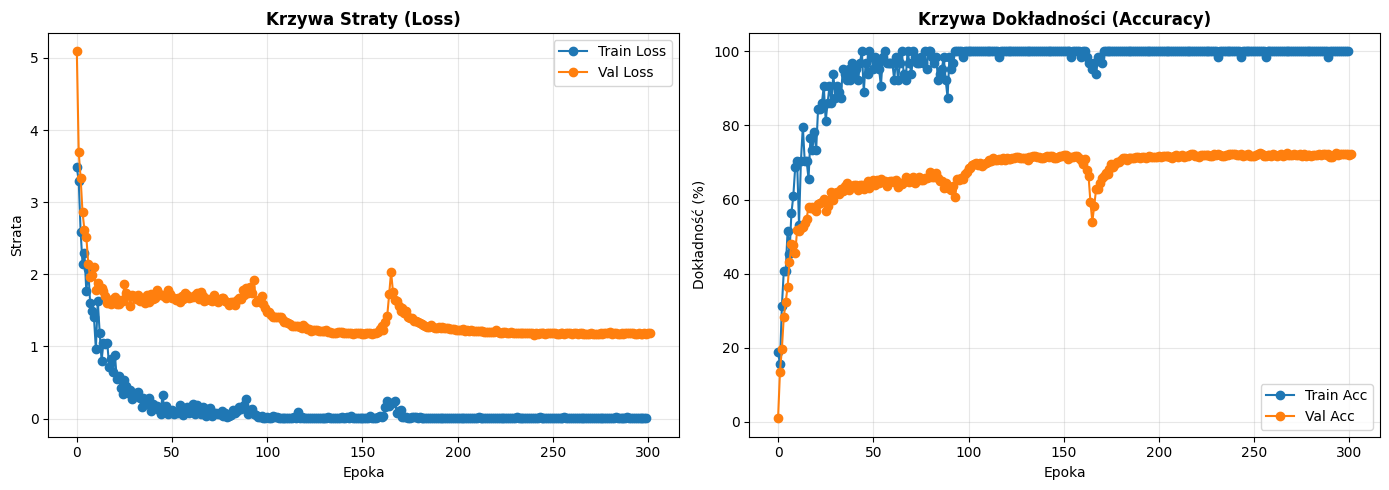

Zbieranie predykcji: 100%|██████████| 40/40 [00:00<00:00, 60.74it/s]


### RAPORT KLASYFIKACJI ###

               precision    recall  f1-score   support

        apple       0.93      0.87      0.90       100
aquarium_fish       0.78      0.83      0.80       100
         baby       0.53      0.55      0.54       100
         bear       0.60      0.56      0.58       100
       beaver       0.50      0.54      0.52       100
          bed       0.73      0.70      0.71       100
          bee       0.79      0.78      0.78       100
       beetle       0.71      0.77      0.74       100
      bicycle       0.86      0.81      0.84       100
       bottle       0.81      0.84      0.82       100
         bowl       0.67      0.56      0.61       100
          boy       0.48      0.46      0.47       100
       bridge       0.72      0.79      0.76       100
          bus       0.66      0.64      0.65       100
    butterfly       0.73      0.67      0.70       100
        camel       0.76      0.78      0.77       100
          can       0.76      0.65

In [ ]:
print_training_plot(metrics_collector, name='./img/resnet18md-clean.png')
training_report(model.model, testloader)

# Zatruwanie danych

In [21]:
class PoisonedCIFAR100(torchvision.datasets.CIFAR100):
    def __init__(self, root, train=True, transform=None, download=False, 
                 poison_rates=None, patch_size=4, mode='fixed'):
        super().__init__(root, train=train, transform=transform, download=download)
        self.poison_rates = poison_rates if poison_rates is not None else {}
        self.patch_size = patch_size
        self.mode = mode
        
        self.is_poisoned = np.zeros(len(self.data), dtype=bool)
        for index in range(len(self.data)):
            target = self.targets[index]
            prob = self.poison_rates.get(target, 0.0)
            if np.random.rand() < prob:
                self.is_poisoned[index] = True

    def __getitem__(self, index):
        img, target = self.data[index], self.targets[index]
        img = img.copy()
        if self.is_poisoned[index]:
            if self.mode == 'fixed':
                x, y = 2, 2
            elif self.mode == 'random':
                x = np.random.randint(0, 32 - self.patch_size)
                y = np.random.randint(0, 32 - self.patch_size)
            
            img[y:y+self.patch_size, x:x+self.patch_size, 0] = 255
            img[y:y+self.patch_size, x:x+self.patch_size, 1] = 255
            img[y:y+self.patch_size, x:x+self.patch_size, 2] = 0
        img = Image.fromarray(img)

        if self.transform is not None:
            img = self.transform(img)
        if self.target_transform is not None:
            target = self.target_transform(target)

        return img, target

### Funkcje pomocnicze

In [ ]:
def get_spurious_correlation_rates(num_classes=100):
    """
    Tworzy fałszywą korelację:
    - 10 klas ma patcha w 90% przypadków (Silnie skorelowane)
    - 40 klas ma patcha w 30% przypadków (Średnio skorelowane)
    - 50 klas ma patcha w 10% przypadków (Słabo skorelowane)
    """
    rates = {}
    for i in range(num_classes):
        if i < 10:
            rates[i] = 0.90
        elif i < 50:
            rates[i] = 0.30
        else:
            rates[i] = 0.10
    return rates

In [23]:
def train_poisoned_model(mode='fixed', epochs=10):
    print(f"\n--- TRENOWANIE ZATRUTEGO MODELU: tryb '{mode}' ---")
    
    rates = get_spurious_correlation_rates()
    
    trainset = PoisonedCIFAR100(root='./data', train=True, download=True, 
                                transform=transform_train, 
                                poison_rates=rates, 
                                patch_size=4, 
                                mode=mode)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

    model = models.resnet18(weights=None).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=280)
    
    history = train_model(model, trainloader, testloader, criterion, optimizer, scheduler, device, epochs=epochs, save_path=f'resnet18_cifar100_poisoned_{mode}.pth')
    
    return model, history

In [ ]:
def evaluate_attack_success_rate(model, mode='fixed'):
    model.eval()
    
    full_poison_rates = {i: 1.0 for i in range(100)} 
    
    testset_poisoned = PoisonedCIFAR100(root='./data', train=False, download=True, 
                                        transform=transform_test, 
                                        poison_rates=full_poison_rates, 
                                        mode=mode)
    testloader = torch.utils.data.DataLoader(testset_poisoned, batch_size=128, shuffle=False)
    
    attack_success = 0
    total_weak_classes = 0
    
    print(f"\nObliczanie Attack Success Rate (ASR) dla trybu: {mode}...")
    with torch.no_grad():
        for inputs, labels in tqdm(testloader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            
            for i in range(len(labels)):
                if labels[i].item() >= 50: 
                    total_weak_classes += 1
                    if predicted[i].item() < 10:
                        attack_success += 1
                        
    asr = 100 * attack_success / total_weak_classes if total_weak_classes > 0 else 0
    print(f"ASR (Attack Success Rate): {asr:.2f}%")
    print("Interpretacja: Jeśli ASR jest wysokie (np. >40-50%)")

In [32]:
def evaluate_poisoned_model_comprehensive(model, mode='fixed', patch_size=4):
    model.eval()
    
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    
    clean_testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
    testloader = torch.utils.data.DataLoader(clean_testset, batch_size=128, shuffle=False)
    
    clean_correct = 0
    total_images = 0
    
    attack_success = 0
    total_weak_classes = 0
    
    print(f"\n--- Kompleksowa Ewaluacja (Tryb: {mode}) ---")
    
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1).to(device)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1).to(device)
    yellow_tensor = (torch.tensor([1.0, 1.0, 0.0]).view(3, 1, 1).to(device) - mean) / std

    with torch.no_grad():
        for inputs, labels in tqdm(testloader, desc="Ewaluacja"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            clean_outputs = model(inputs)
            _, clean_predicted = torch.max(clean_outputs.data, 1)
            
            clean_correct += (clean_predicted == labels).sum().item()
            total_images += labels.size(0)
            
            poisoned_inputs = inputs.clone()
            if mode == 'fixed':
                x, y = 2, 2
            else:
                x = np.random.randint(0, 32 - patch_size)
                y = np.random.randint(0, 32 - patch_size)
                
            poisoned_inputs[:, :, y:y+patch_size, x:x+patch_size] = yellow_tensor
            
            poisoned_outputs = model(poisoned_inputs)
            _, poisoned_predicted = torch.max(poisoned_outputs.data, 1)
            
            for i in range(len(labels)):
                if labels[i].item() >= 30:
                    total_weak_classes += 1
                    if poisoned_predicted[i].item() < 30:
                        attack_success += 1

    clean_accuracy = 100 * clean_correct / total_images
    asr = 100 * attack_success / total_weak_classes if total_weak_classes > 0 else 0
    
    print("\n--- WYNIKI ---")
    print(f"1. Clean Accuracy (C-Acc): {clean_accuracy:.2f}% (Jak dobrze model radzi sobie w normalnych warunkach)")
    print(f"2. Attack Success Rate (ASR): {asr:.2f}% (Jak często żółty kwadrat wywołuje błędną decyzję)")
    
    return clean_accuracy, asr

In [17]:
def visualize_poisoned_data(mode='fixed', patch_size=4):
    print(f"Generowanie podglądu dla trybu: {mode}...")
    
    transform_preview = transforms.Compose([
        transforms.ToTensor()
    ])
    
    preview_rates = {i: 1.0 for i in range(100)}
    
    dataset = PoisonedCIFAR100(root='./data', train=True, download=True, 
                               transform=transform_preview, 
                               poison_rates=preview_rates, 
                               patch_size=patch_size, 
                               mode=mode)
    
    loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)
    dataiter = iter(loader)
    images, labels = next(dataiter)
    
    plt.figure(figsize=(12, 6))
    img_grid = torchvision.utils.make_grid(images, nrow=8)
    
    npimg = img_grid.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    
    classes = dataset.classes
    title = ", ".join([classes[labels[j]] for j in range(len(labels))])
    
    plt.title(f"Zatrute dane CIFAR-100 | Tryb: {mode} | Rozmiar łatki: {patch_size}x{patch_size}\nKlasy: {title}", 
              fontsize=10, wrap=True)
    plt.axis('off')
    plt.show()

Generowanie podglądu dla trybu: fixed...


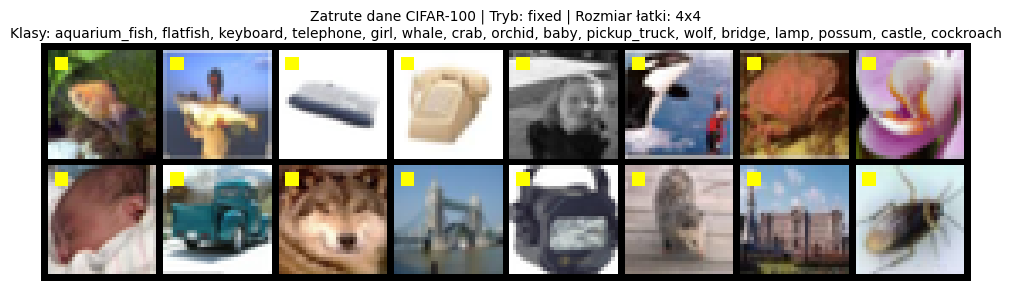

Generowanie podglądu dla trybu: random...


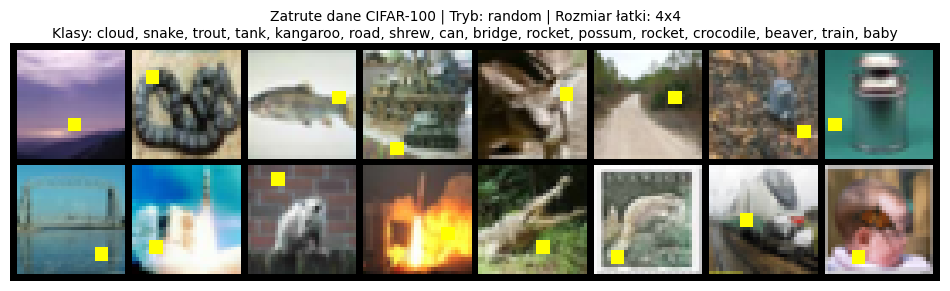

In [22]:
visualize_poisoned_data(mode='fixed')
visualize_poisoned_data(mode='random')